<a href="https://colab.research.google.com/github/Gema-Villanueva/Brecha-Digital-2/blob/main/ultimasmodificaciones_brechasDigitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset construido a partir de datos oficiales del INE y del Ministerio de Educación integrando variables socioeconómicas y de acceso digital.
Se realiza un proceso de limpieza de datos que incluye la normalización de nombres, conversión de formatos numéricos y unificación de datasets.

In [334]:
!pip install -q pandas numpy

In [335]:
#Importamos las librerías necesarias para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [336]:
#Convertimos los números de formato español (con coma) a formato python (con punto)
def to_float_es(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x == "":
        return np.nan

    if "," in x:
        x = x.replace(".", "").replace(",", ".")
    else:
        x = x.replace(".", "")

    try:
        return float(x)
    except:
        return np.nan


#limpiamos y unificamos los nombres de las comunidades autónomas
def clean_name(name):
    if pd.isna(name):
        return None

    name = str(name).strip()
    name = name.replace("\xa0", " ").strip()

    # quitar códigos delante tipo "01 Andalucía"
    name = pd.Series([name]).str.replace(r"^\d+\s*", "", regex=True).iloc[0]

    cambios = {
        "Asturias, Principado de": "Asturias",
        "Principado de Asturias": "Asturias",
        "Asturias (Principado de)": "Asturias",

        "Balears, Illes": "Baleares",
        "Illes Balears": "Baleares",
        "Balears (Illes)": "Baleares",

        "Madrid, Comunidad de": "Madrid",
        "Comunidad de Madrid": "Madrid",
        "Madrid (Comunidad de)": "Madrid",

        "Murcia, Región de": "Murcia",
        "Región de Murcia": "Murcia",
        "Murcia (Región de)": "Murcia",

        "Navarra, Comunidad Foral de": "Navarra",
        "Comunidad Foral de Navarra": "Navarra",
        "Navarra (Comunidad Foral de)": "Navarra",

        "Rioja, La": "La Rioja",
        "La Rioja": "La Rioja",
        "Rioja (La)": "La Rioja",

        "Comunitat Valenciana": "Comunidad Valenciana",
        "Castilla - La Mancha": "Castilla-La Mancha",

        "Total nacional": "Total Nacional",
        "TOTAL": "Total Nacional"
    }

    return cambios.get(name, name)

In [337]:
CCAA_17 = [
    "Andalucía",
    "Aragón",
    "Asturias",
    "Baleares",
    "Canarias",
    "Cantabria",
    "Castilla y León",
    "Castilla-La Mancha",
    "Cataluña",
    "Comunidad Valenciana",
    "Extremadura",
    "Galicia",
    "Madrid",
    "Murcia",
    "Navarra",
    "País Vasco",
    "La Rioja"
]

In [338]:
#cargamos datasets desde fuentes oficiales INE y Ministerio
internet_raw = pd.read_csv("https://www.ine.es/jaxi/files/tpx/csv_bd/50039.csv", sep="\t")
renta_raw = pd.read_csv("https://www.ine.es/jaxiT3/files/t/csv_bd/68338.csv", sep="\t")
arope_raw = pd.read_csv("https://www.ine.es/jaxiT3/files/t/csv_bdsc/60264.csv", sep=";")
paro_raw = pd.read_csv("https://www.ine.es/jaxiT3/files/t/csv_bdsc/67565.csv", sep=";")
orden_raw = pd.read_csv(
    "https://estadisticas.educacion.gob.es/EducaJaxiPx/files/_px/es/csv_bdsc/no-universitaria/centros/tic/series/l0/series_1_4.csv_bdsc?nocab=1",
    sep=";"
)

In [339]:
#Filtramos los datos de acceso a banda ancha para el año 2021
internet = internet_raw.copy()

internet["comunidad"] = internet["Comunidades Autónomas"].apply(clean_name)
internet["anio"] = pd.to_numeric(internet["Periodo"], errors="coerce")
internet["valor"] = internet["Total"].apply(to_float_es)

internet_2021 = (
    internet[internet["Tipo de equipamiento"] == "Viviendas con conexión de Banda Ancha"]
    .loc[:, ["comunidad", "anio", "valor"]]
    .rename(columns={"valor": "banda_ancha_pct"})
)

internet_2021 = internet_2021[
    (internet_2021["anio"] == 2021) &
    (internet_2021["comunidad"].isin(CCAA_17))
].copy()

internet_2021["anio"] = internet_2021["anio"].astype(int)

In [340]:
#Filtramos la renta media por comunidad autónoma
renta = renta_raw.copy()

renta["comunidad"] = renta["Comunidad autónoma"].apply(clean_name)
renta["anio"] = pd.to_numeric(renta["Periodo"], errors="coerce")
renta["valor"] = renta["Total"].apply(to_float_es)

renta_2021 = (
    renta[renta["Renta media y mediana"].astype(str).str.contains("renta media", case=False, na=False)]
    .loc[:, ["comunidad", "anio", "valor"]]
    .rename(columns={"valor": "renta_media"})
)

renta_2021 = renta_2021[
    (renta_2021["anio"] == 2021) &
    (renta_2021["comunidad"].isin(CCAA_17))
].copy()

renta_2021 = renta_2021.groupby("comunidad", as_index=False)["renta_media"].mean()
renta_2021["anio"] = 2021

In [341]:
#Filtramos el indicador de riesgo de pobreza y exclusión social
arope = arope_raw.copy()

col_comunidad_arope = [c for c in arope.columns if "Comunidades" in c or "comunidad" in c.lower()][0]
col_periodo_arope = [c for c in arope.columns if "Periodo" in c or "periodo" in c.lower()][0]
col_valor_arope = "Total" if "Total" in arope.columns else arope.columns[-1]

arope["comunidad"] = arope[col_comunidad_arope].apply(clean_name)
arope["anio"] = pd.to_numeric(arope[col_periodo_arope], errors="coerce")
arope["valor"] = arope[col_valor_arope].apply(to_float_es)

posibles_indicadores = [
    c for c in arope.columns
    if c not in [col_comunidad_arope, col_periodo_arope, col_valor_arope, "comunidad", "anio", "valor"]
]
indicador_col = posibles_indicadores[0]

arope_2021 = (
    arope[arope[indicador_col].astype(str).str.contains("riesgo de pobreza|arope", case=False, na=False)]
    .loc[:, ["comunidad", "anio", "valor"]]
    .rename(columns={"valor": "arope_pct"})
)

arope_2021 = arope_2021[
    (arope_2021["anio"] == 2021) &
    (arope_2021["comunidad"].isin(CCAA_17))
].copy()

arope_2021 = arope_2021.groupby("comunidad", as_index=False)["arope_pct"].mean()
arope_2021["anio"] = 2021

In [342]:
#Filtramos la tasa de desempleo
paro = paro_raw.copy()

col_comunidad_paro = [c for c in paro.columns if "Comunidades" in c or "comunidad" in c.lower()][0]
col_periodo_paro = [c for c in paro.columns if "Periodo" in c or "periodo" in c.lower()][0]
col_valor_paro = "Total" if "Total" in paro.columns else paro.columns[-1]

paro["comunidad"] = paro[col_comunidad_paro].apply(clean_name)
paro["valor"] = paro[col_valor_paro].apply(to_float_es)
paro["anio"] = paro[col_periodo_paro].astype(str).str.extract(r"(\d{4})").astype(float)

if "Sexo" in paro.columns:
    paro = paro[paro["Sexo"] == "Ambos sexos"].copy()

if "Edad" in paro.columns:
    paro = paro[paro["Edad"] == "Total"].copy()

paro_2021 = (
    paro[(paro["anio"] == 2021) & (paro["comunidad"].isin(CCAA_17))]
    .groupby("comunidad", as_index=False)["valor"].mean()
    .rename(columns={"valor": "paro_pct"})
)

paro_2021["anio"] = 2021

In [343]:
#Datos sobre disponibilidad de ordenadores en centros educativos
orden = orden_raw.copy()

orden["comunidad"] = orden["Comunidad autónoma"].apply(clean_name)
orden["valor"] = orden["Total"].apply(to_float_es)

orden_2021 = (
    orden[
        (orden["Titularidad"] == "TODOS LOS CENTROS") &
        (orden["periodo"] == "2020-2021") &
        (orden["comunidad"].isin(CCAA_17))
    ]
    .loc[:, ["comunidad", "valor"]]
    .rename(columns={"valor": "ordenadores_unidad"})
)

orden_2021 = orden_2021.groupby("comunidad", as_index=False)["ordenadores_unidad"].mean()

In [344]:
#Unimos todos los datasets en un único dataset maestro
df = internet_2021.merge(renta_2021, on=["comunidad", "anio"], how="inner")
df = df.merge(arope_2021, on=["comunidad", "anio"], how="inner")
df = df.merge(paro_2021, on=["comunidad", "anio"], how="inner")
df = df.merge(orden_2021, on="comunidad", how="left")

df = df[df["comunidad"].isin(CCAA_17)].copy()
df = df.sort_values("comunidad").reset_index(drop=True)

In [345]:
#Nos aseguramos que estén todas las comunidades autónomas
display(df)
print("Shape final:", df.shape)
print("Comunidades finales:", sorted(df["comunidad"].unique()))

,comunidad,anio,banda_ancha_pct,renta_media,arope_pct,paro_pct,ordenadores_unidad
0,Andalucía,2021,94.50,13752.50,35.50,21.86,5.70
1,Aragón,2021,96.30,18751.00,17.90,10.34,6.10
2,Asturias,2021,94.30,17384.50,23.35,12.35,8.10
3,Baleares,2021,97.30,16316.00,20.00,14.33,NaN
4,Canarias,2021,96.70,14528.50,33.10,23.48,7.90
5,Cantabria,2021,95.00,17511.50,18.40,11.27,NaN
6,Castilla y León,2021,95.60,17434.50,20.50,15.67,5.10
7,Castilla-La Mancha,2021,94.40,7794.50,29.95,11.62,5.60
8,Cataluña,2021,96.90,19877.50,18.55,11.70,10.20
9,Comunidad Valenciana,2021,96.80,15873.50,27.85,16.10,5.20


Shape final: (17, 7)
Comunidades finales: ['Andalucía', 'Aragón', 'Asturias', 'Baleares', 'Canarias', 'Cantabria', 'Castilla y León', 'Castilla-La Mancha', 'Cataluña', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'La Rioja', 'Madrid', 'Murcia', 'Navarra', 'País Vasco']


In [346]:
# ================================
#      LIMPIEZA DE DATOS
# ================================

print("\n⚠️ Valores nulos:")
print(df.isnull().sum())

print("\n OUTLIERS DETECTADOS:\n")
#Por medio de éste código sabremos (qué columna tiene outliers, en qué comunidad y qué valor es raro)

for col in df.select_dtypes(include=['float64', 'int64']).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]

    if len(outliers) > 0:
        print(f"🔴 {col}: {len(outliers)} outliers")
        print(outliers[["comunidad", col]])
        print()
# Rellenar nulos con la media
df["ordenadores_unidad"] = df["ordenadores_unidad"].fillna(df["ordenadores_unidad"].mean())



⚠️ Valores nulos:
comunidad             0
anio                  0
banda_ancha_pct       0
renta_media           0
arope_pct             0
paro_pct              0
ordenadores_unidad    3
dtype: int64

 OUTLIERS DETECTADOS:

🔴 renta_media: 1 outliers
            comunidad  renta_media
7  Castilla-La Mancha      7794.50

🔴 paro_pct: 2 outliers
   comunidad  paro_pct
0  Andalucía     21.86
4   Canarias     23.48



In [347]:
# ================================
#     VALIDACIÓN FINAL DATASET
# ================================

print("📊 Dimensiones:")
print(df.shape)

print("\n📌 Columnas:")
print(df.columns.tolist())

print("\n📌 Tipos de datos:")
print(df.dtypes)

print("\nNulos después de limpiar:")
print(df.isnull().sum())

print("\n📈 Estadísticas:")
desc = df.describe()
display(desc.style.format({
    col: "{:.0f}" if df[col].dtype == "int64" else "{:.2f}"
    for col in desc.columns
}))

print("\n🗺️ Comunidades únicas:")
print(df["comunidad"].unique())

print("\n🔢 Número de comunidades:")
print(df["comunidad"].nunique())

print("\n🔁 Duplicados:")
print(df.duplicated().sum())

📊 Dimensiones:
(17, 7)

📌 Columnas:
['comunidad', 'anio', 'banda_ancha_pct', 'renta_media', 'arope_pct', 'paro_pct', 'ordenadores_unidad']

📌 Tipos de datos:
comunidad              object
anio                    int64
banda_ancha_pct       float64
renta_media           float64
arope_pct             float64
paro_pct              float64
ordenadores_unidad    float64
dtype: object

Nulos después de limpiar:
comunidad             0
anio                  0
banda_ancha_pct       0
renta_media           0
arope_pct             0
paro_pct              0
ordenadores_unidad    0
dtype: int64

📈 Estadísticas:


,anio,banda_ancha_pct,renta_media,arope_pct,paro_pct,ordenadores_unidad
count,17,17.00,17.00,17.00,17.00,17.00
mean,2021,95.68,15736.65,23.38,14.09,7.72
std,0,1.26,3903.96,7.33,4.13,2.15
min,2021,93.20,7794.50,12.25,10.29,5.10
25%,2021,94.60,13752.50,18.40,11.56,5.70
50%,2021,95.60,16097.00,20.50,11.70,7.72
75%,2021,96.80,17511.50,29.95,15.67,8.60
max,2021,97.50,21886.00,35.50,23.48,13.10



🗺️ Comunidades únicas:
['Andalucía' 'Aragón' 'Asturias' 'Baleares' 'Canarias' 'Cantabria'
 'Castilla y León' 'Castilla-La Mancha' 'Cataluña' 'Comunidad Valenciana'
 'Extremadura' 'Galicia' 'La Rioja' 'Madrid' 'Murcia' 'Navarra'
 'País Vasco']

🔢 Número de comunidades:
17

🔁 Duplicados:
0


In [348]:

df.to_csv("dataset_maestro_limpio.csv", index=False, encoding="utf-8")
print("✅ Dataset guardado")

✅ Dataset guardado


In [349]:
#from google.colab import files
#files.download("dataset_maestro_limpio.csv")


 Vista previa:
   comunidad  anio  banda_ancha_pct  renta_media  arope_pct  paro_pct  \
0  Andalucía  2021            94.50     13752.50      35.50     21.86   
1     Aragón  2021            96.30     18751.00      17.90     10.34   
2   Asturias  2021            94.30     17384.50      23.35     12.35   
3   Baleares  2021            97.30     16316.00      20.00     14.33   
4   Canarias  2021            96.70     14528.50      33.10     23.48   

   ordenadores_unidad  
0                5.70  
1                6.10  
2                8.10  
3                7.72  
4                7.90  


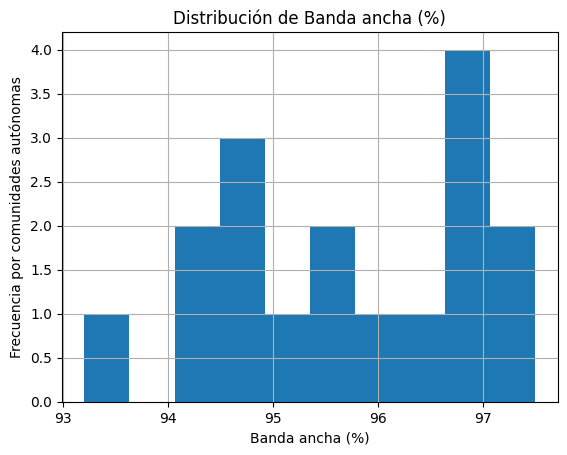

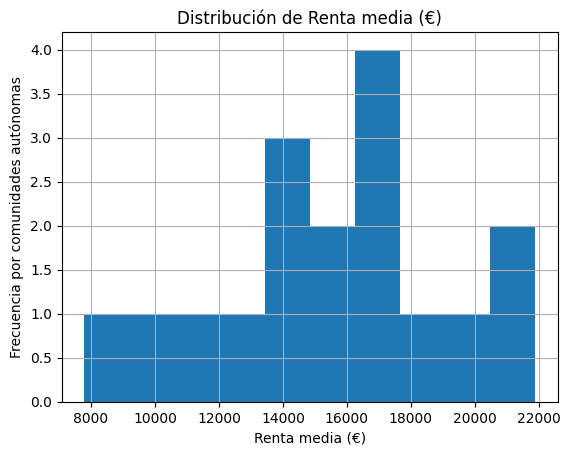

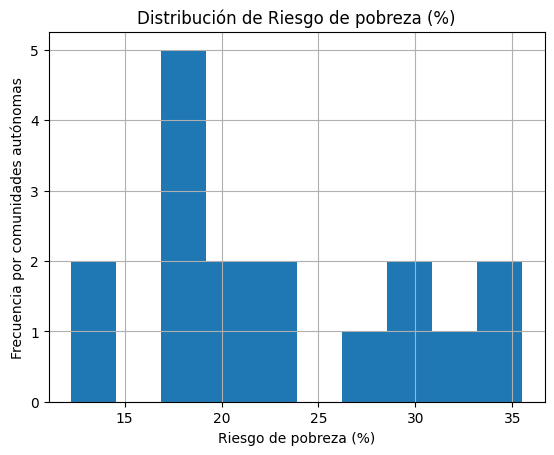

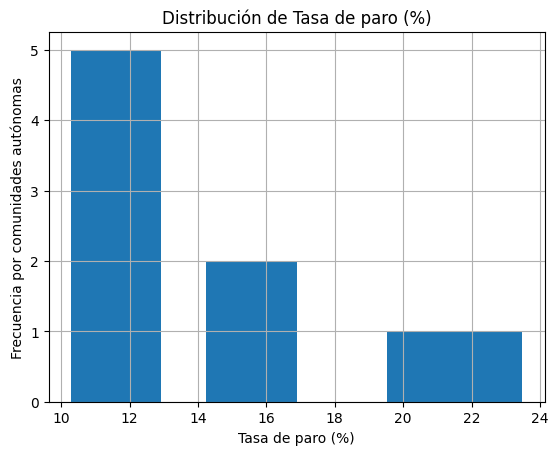

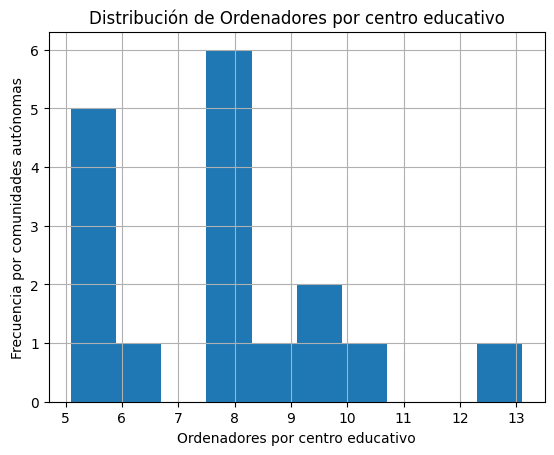

In [350]:
#Visualizamos la tabla con los campos limpios

print("\n Vista previa:")

pd.options.display.float_format = '{:.2f}'.format
print(df.head())

# ================================
# 📊 HISTOGRAMAS
# ================================


nombres = {
    "banda_ancha_pct": "Banda ancha (%)",
    "renta_media": "Renta media (€)",
    "arope_pct": "Riesgo de pobreza (%)",
    "paro_pct": "Tasa de paro (%)",
    "ordenadores_unidad": "Ordenadores por centro educativo"
}

columnas = ["banda_ancha_pct", "renta_media", "arope_pct", "paro_pct", "ordenadores_unidad"]

for col in columnas:
    plt.figure()
    plt.hist(df[col], bins=10)

    plt.title(f"Distribución de {nombres[col]}")

    plt.xlabel(nombres[col])
    plt.ylabel("Frecuencia por comunidades autónomas")

    plt.grid(True)
    plt.show()


In [351]:
#CORRELACIONES

# ================================
#    MATRIZ DE CORRELACIÓN
# ================================

nombres = {
    "banda_ancha_pct": "Acceso a Internet (%)",
    "renta_media": "Renta media (€)",
    "arope_pct": "Riesgo de pobreza (%)",
    "paro_pct": "Tasa de paro (%)",
    "ordenadores_unidad": "Ordenadores por centro"
}

corr = df.rename(columns=nombres)[list(nombres.values())].corr()

print("\n🔗 MATRIZ DE CORRELACIÓN:\n")
print(corr.round(2))




🔗 MATRIZ DE CORRELACIÓN:

                        Acceso a Internet (%)  Renta media (€)  \
Acceso a Internet (%)                    1.00             0.17   
Renta media (€)                          0.17             1.00   
Riesgo de pobreza (%)                   -0.21            -0.56   
Tasa de paro (%)                         0.03            -0.27   
Ordenadores por centro                  -0.13             0.58   

                        Riesgo de pobreza (%)  Tasa de paro (%)  \
Acceso a Internet (%)                   -0.21              0.03   
Renta media (€)                         -0.56             -0.27   
Riesgo de pobreza (%)                    1.00              0.82   
Tasa de paro (%)                         0.82              1.00   
Ordenadores por centro                  -0.38             -0.28   

                        Ordenadores por centro  
Acceso a Internet (%)                    -0.13  
Renta media (€)                           0.58  
Riesgo de pobreza (%)     

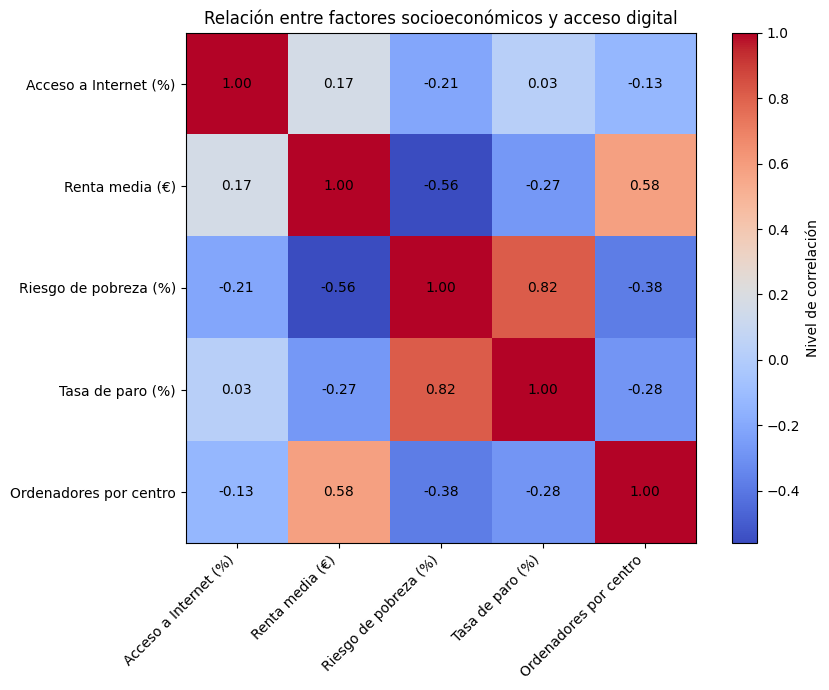

In [352]:
# ================================
#          HEATMAP
# ================================

plt.figure(figsize=(9,7))
plt.imshow(corr, cmap='coolwarm', interpolation='none')

plt.colorbar(label="Nivel de correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Relación entre factores socioeconómicos y acceso digital")

# Mostrar valores dentro del gráfico
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.tight_layout()
plt.show()



IDENTIFICACIÓN DE VARIABLES CLAVE

Para identificar las variables más importantes del proyecto, se ha analizado la correlación entre el acceso a internet (%) y el resto de variables socioeconómicas del dataset.

El objetivo es comprobar qué factores están más relacionados con la brecha digital en las comunidades autónomas. Para ello, se han ordenado las correlaciones según su valor absoluto, de manera que las variables con valores más altos se consideran las más influyentes.

Una correlación positiva indica que ambas variables tienden a aumentar juntas, mientras que una correlación negativa indica que cuando una sube, la otra tiende a bajar.

In [353]:
# ================================
#   IDENTIFICACIÓN DE VARIABLES CLAVE
# ================================

# Seleccionamos solo las correlaciones con la variable objetivo
corr_objetivo = corr["Acceso a Internet (%)"].drop("Acceso a Internet (%)")

# Ordenamos por valor absoluto para ver cuáles influyen más
variables_clave = corr_objetivo.abs().sort_values(ascending=False)

print("🔑 VARIABLES CLAVE RELACIONADAS CON EL ACCESO A INTERNET:\n")
print(variables_clave)

print("\n📌 CORRELACIONES REALES (con signo):\n")
print(corr_objetivo.sort_values(ascending=False))

🔑 VARIABLES CLAVE RELACIONADAS CON EL ACCESO A INTERNET:

Riesgo de pobreza (%)    0.21
Renta media (€)          0.17
Ordenadores por centro   0.13
Tasa de paro (%)         0.03
Name: Acceso a Internet (%), dtype: float64

📌 CORRELACIONES REALES (con signo):

Renta media (€)           0.17
Tasa de paro (%)          0.03
Ordenadores por centro   -0.13
Riesgo de pobreza (%)    -0.21
Name: Acceso a Internet (%), dtype: float64


La variable más relacionada con el acceso a internet es el riesgo de pobreza (-0.21), seguida de la renta media (0.17).

El resto de variables presentan relaciones débiles, lo que indica que la brecha digital depende de varios factores y no de uno solo.

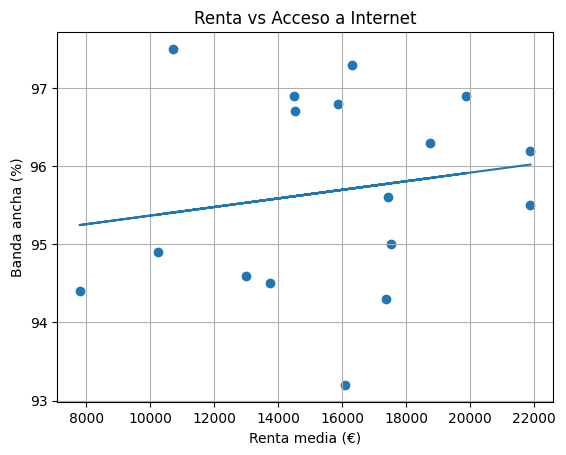

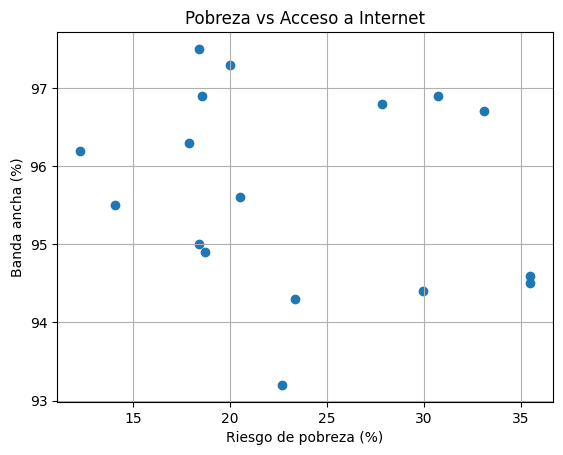

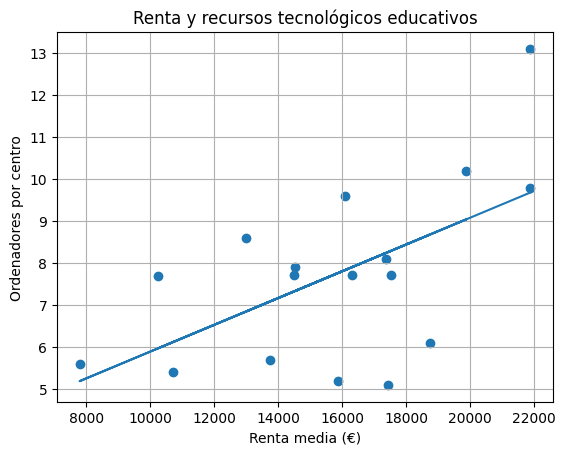

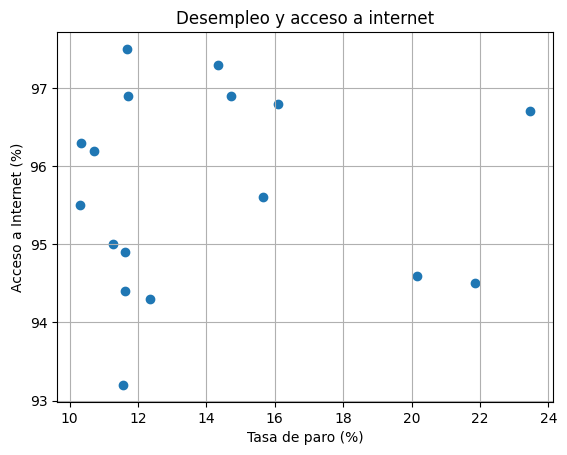

In [354]:
#======================================
#     GRÁFICOS DE DISPERSIÓN
#======================================

#========================
# RENTA VS INTERNET
#=======================

x = df["renta_media"]
y = df["banda_ancha_pct"]

plt.figure()
plt.scatter(x, y)

z = np.polyfit(x, y, 1); plt.plot(x, np.poly1d(z)(x))

plt.xlabel("Renta media (€)")
plt.ylabel("Banda ancha (%)")
plt.title("Renta vs Acceso a Internet")

plt.grid(True)
plt.show()

#===========================
# POBREZA VS INTERNET
#===========================

plt.figure()
plt.scatter(df["arope_pct"], df["banda_ancha_pct"])

plt.xlabel("Riesgo de pobreza (%)")
plt.ylabel("Banda ancha (%)")
plt.title("Pobreza vs Acceso a Internet")

plt.grid(True)
plt.show()


# ================================
# 💰 RENTA vs ORDENADORES
# ================================
x = df["renta_media"]
y = df["ordenadores_unidad"]

plt.figure()
plt.scatter(x, y)

z = np.polyfit(x, y, 1); plt.plot(x, np.poly1d(z)(x))

plt.xlabel("Renta media (€)")
plt.ylabel("Ordenadores por centro")
plt.title("Renta y recursos tecnológicos educativos")

plt.grid(True)
plt.show()

# ================================
# 📉 PARO vs INTERNET
# ================================
plt.figure()
plt.scatter(df["paro_pct"], df["banda_ancha_pct"])

plt.xlabel(nombres["paro_pct"])
plt.ylabel(nombres["banda_ancha_pct"])
plt.title("Desempleo y acceso a internet")

plt.grid(True)
plt.show()


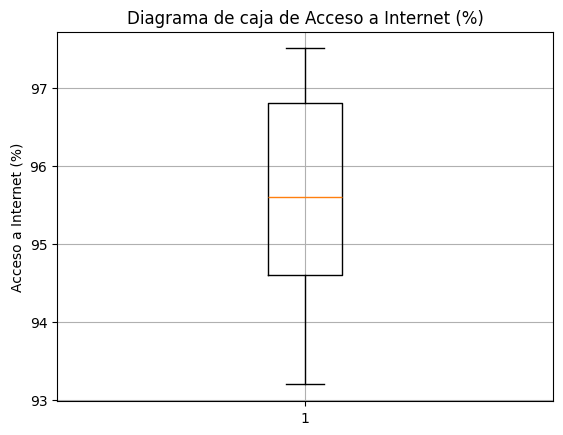

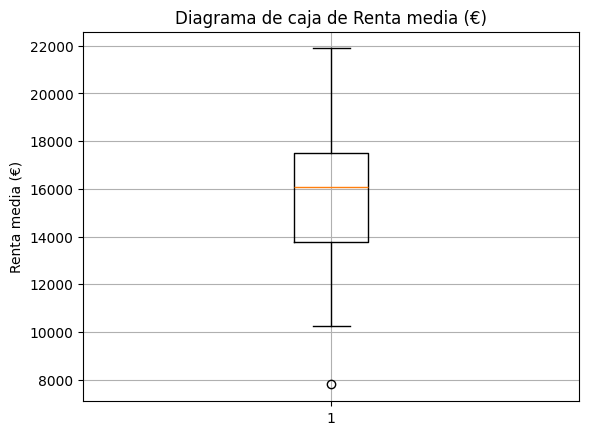

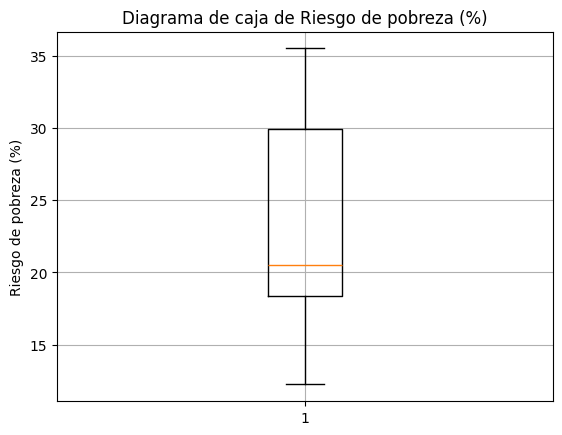

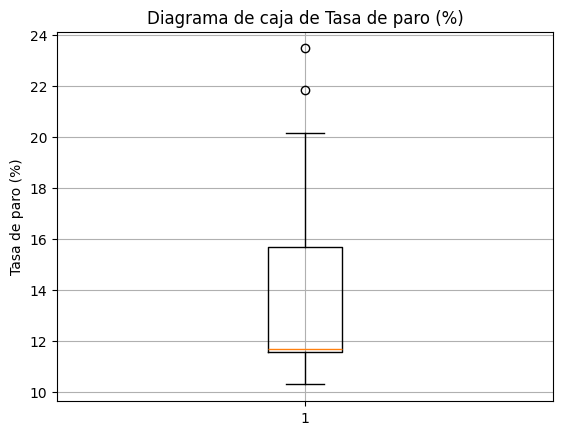

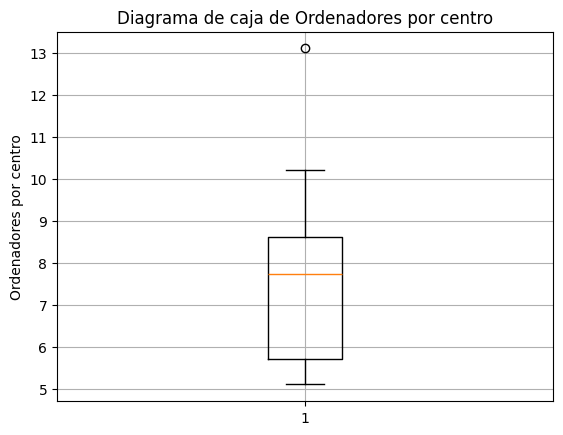

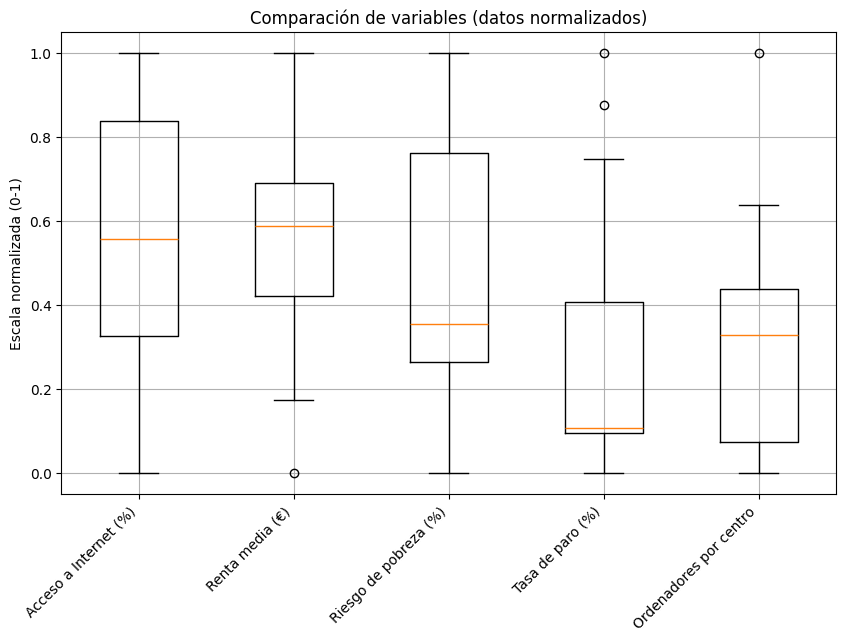

In [355]:
# ================================
#  BOXPLOTS (DIAGRAMAS DE CAJA)
# ================================

# Muestra la distribución de los datos y permite detectar posibles valores atípicos (outliers)
nombres = {
    "banda_ancha_pct": "Acceso a Internet (%)",
    "renta_media": "Renta media (€)",
    "arope_pct": "Riesgo de pobreza (%)",
    "paro_pct": "Tasa de paro (%)",
    "ordenadores_unidad": "Ordenadores por centro"
}

for col, nombre in nombres.items():
    plt.figure()
    plt.boxplot(df[col])

    plt.title(f"Diagrama de caja de {nombre}")
    plt.ylabel(nombre)

    plt.grid(True)
    plt.show()

    # ================================
# 📦 BOXPLOT NORMALIZADO
# ================================

from sklearn.preprocessing import MinMaxScaler

nombres = {
    "banda_ancha_pct": "Acceso a Internet (%)",
    "renta_media": "Renta media (€)",
    "arope_pct": "Riesgo de pobreza (%)",
    "paro_pct": "Tasa de paro (%)",
    "ordenadores_unidad": "Ordenadores por centro"
}

columnas = list(nombres.keys())
etiquetas = list(nombres.values())

# Normalización
scaler = MinMaxScaler()
df_normalizado = pd.DataFrame(
    scaler.fit_transform(df[columnas]),
    columns=columnas
)

plt.figure(figsize=(10,6))
plt.boxplot([df_normalizado[col] for col in columnas])

plt.xticks(range(1, len(etiquetas)+1), etiquetas, rotation=45, ha="right")
plt.title("Comparación de variables (datos normalizados)")
plt.ylabel("Escala normalizada (0-1)")

plt.grid(True)
plt.show()

=== REGRESIÓN LINEAL ===
MAE: 0.7833928298002135
RMSE: 0.9578480543769871
R2: -0.5419712525609746

=== RANDOM FOREST ===
MAE: 0.830500000000022
RMSE: 0.8720639311426971
R2: -0.27814369747908385

Modelo Random Forest guardado como 'modelo_regresion.pkl'

Predicción de acceso a internet para el ejemplo:
95.78800000000001


,comunidad,anio,banda_ancha_pct,renta_media,arope_pct,paro_pct,ordenadores_unidad,prioridad
0,Andalucía,2021,94.50,13752.50,35.50,21.86,5.70,Alta
1,Aragón,2021,96.30,18751.00,17.90,10.34,6.10,Media
2,Asturias,2021,94.30,17384.50,23.35,12.35,8.10,Media
3,Baleares,2021,97.30,16316.00,20.00,14.33,7.72,Media
4,Canarias,2021,96.70,14528.50,33.10,23.48,7.90,Alta



Tabla comparativa de escenarios:


,comunidad,actual,1_anio,3_anios,5_anios
0,Andalucía,95.73,95.81,96.27,96.39
1,Aragón,95.45,95.61,95.61,95.43
2,Asturias,94.98,95.18,94.09,94.61
3,Baleares,96.98,96.79,96.27,96.52
4,Canarias,96.40,96.39,96.44,96.05


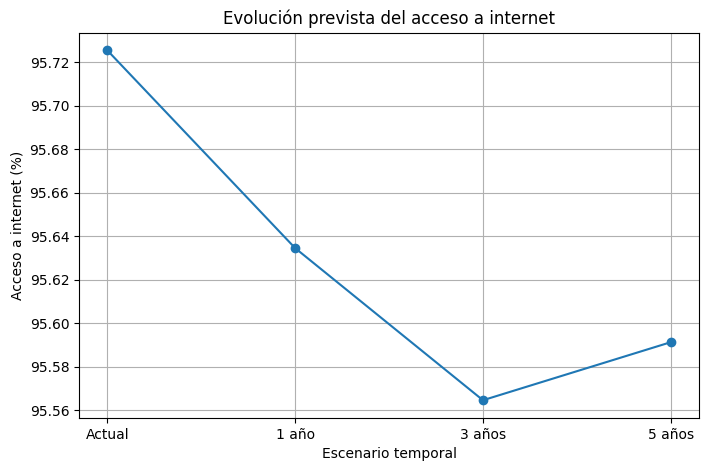


Mejora media estimada a 5 años: -0.13 puntos porcentuales


In [356]:
# Definimos las variables predictoras (X) y la variable objetivo (y).
# Queremos predecir el porcentaje de acceso a internet (banda ancha)
# a partir de variables socioeconómicas.

X = df[["renta_media", "paro_pct", "arope_pct"]]
y = df["banda_ancha_pct"]

#Entrenamiento del modelo
# Dividimos los datos en dos partes:
# - entrenamiento: para enseñar al modelo
# - prueba: para comprobar su rendimiento con datos no vistos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 🔄 NORMALIZACIÓN DE DATOS
# ================================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# - Regresión lineal: modelo sencillo y fácil de interpretar
# - Random Forest: modelo más potente para captar relaciones no lineales

#Modelo 1: Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)

# Modelo 2: Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

#Predicciones
# Generamos predicciones con ambos modelos sobre el conjunto de prueba.
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)


#EVALUACIÓN DE LOS MODELOS
# Evaluamos los modelos mediante:
# - MAE: error absoluto medio
# - RMSE: raíz del error cuadrático medio
# - R²: capacidad explicativa del modelo

print("=== REGRESIÓN LINEAL ===")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2:", r2_score(y_test, lr_preds))

print("\n=== RANDOM FOREST ===")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2:", r2_score(y_test, rf_preds))

#GUARDAR MODELO
# Guardamos el modelo Random Forest para poder reutilizarlo más adelante.

joblib.dump(rf, "modelo_regresion.pkl")
print("\nModelo Random Forest guardado como 'modelo_regresion.pkl'")


#PREDICCIÓN DE EJEMPLO
# ---------------------------
# Simulamos una comunidad o zona ficticia con unos valores concretos
# de renta, paro y riesgo de pobreza para ver la predicción del modelo.

murcia = pd.DataFrame({
    "renta_media": [22000],
    "paro_pct": [18],
    "arope_pct": [25]
})

murcia_scaled = scaler.transform(murcia)
prediccion = rf.predict(murcia_scaled)

print("\nPredicción de acceso a internet para el ejemplo:")
print(prediccion[0])


#Clasifica escuelas publicas en categorias de prioridad alta, media y baja basánsose en su presupuesto

def prioridad(row):
    if row["renta_media"] < 20000 and row["paro_pct"] > 20:
        return "Alta"
    elif row["renta_media"] < 30000:
        return "Media"
    else:
        return "Baja"

df["prioridad"] = df.apply(prioridad, axis=1)
display(df.head())

#Muestra el árbol de decisión


# ---------------------------
# Simulamos cómo podría evolucionar el acceso a internet si mejoran ciertas variables socioeconómicas con el paso del tiempo.
# Creamos una copia del dataset base
df_base = df.copy()

# Escenario actual
df_actual = df_base.copy()
df_actual["pred_actual"] = rf.predict(scaler.transform(df_actual[["renta_media", "paro_pct", "arope_pct"]]))
# Escenario a 1 año
df_1 = df_base.copy()
df_1["renta_media"] *= 1.03
df_1["paro_pct"] *= 0.97
df_1["arope_pct"] *= 0.98
df_1["pred_1_anio"] = rf.predict(scaler.transform(df_1[["renta_media", "paro_pct", "arope_pct"]]))
# Escenario a 3 años
df_3 = df_base.copy()
df_3["renta_media"] *= 1.08
df_3["paro_pct"] *= 0.92
df_3["arope_pct"] *= 0.95
df_3["pred_3_anios"] = rf.predict(scaler.transform(df_3[["renta_media", "paro_pct", "arope_pct"]]))

# Escenario a 5 años
df_5 = df_base.copy()
df_5["renta_media"] *= 1.15
df_5["paro_pct"] *= 0.85
df_5["arope_pct"] *= 0.90
df_5["pred_5_anios"] = rf.predict(scaler.transform(df_5[["renta_media", "paro_pct", "arope_pct"]]))

#TABLA COMPARATIVA
# ---------------------------
# Reunimos en una sola tabla las predicciones de cada comunidad autónoma
# en los diferentes escenarios temporales.

df_resultado = df[["comunidad"]].copy()
df_resultado["actual"] = df_actual["pred_actual"]
df_resultado["1_anio"] = df_1["pred_1_anio"]
df_resultado["3_anios"] = df_3["pred_3_anios"]
df_resultado["5_anios"] = df_5["pred_5_anios"]

print("\nTabla comparativa de escenarios:")
display(df_resultado.head())


#VISUALIZACIÓN DE LA EVOLUCIÓN
# ---------------------------
# Representamos la media del acceso a internet predicho en cada escenario
# para observar la evolución global esperada.

valores = [
    df_resultado["actual"].mean(),
    df_resultado["1_anio"].mean(),
    df_resultado["3_anios"].mean(),
    df_resultado["5_anios"].mean()
]

etiquetas = ["Actual", "1 año", "3 años", "5 años"]

plt.figure(figsize=(8, 5))
plt.plot(etiquetas, valores, marker="o")
plt.title("Evolución prevista del acceso a internet")
plt.xlabel("Escenario temporal")
plt.ylabel("Acceso a internet (%)")
plt.grid()
plt.show()


#CONCLUSIÓN BREVE
# ---------------------------
# Calculamos y mostramos la mejora media esperada entre el escenario actual
# y el escenario de 5 años.

mejora_media = df_resultado["5_anios"].mean() - df_resultado["actual"].mean()

print("\nMejora media estimada a 5 años:", round(mejora_media, 2), "puntos porcentuales")

In [357]:
# Creamos y entrenamos la red neuronal (MLP)
# Usamos los mismos datos de entrenamiento definidos anteriormente

mlp = MLPRegressor(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)

In [358]:
# Generamos predicciones con el modelo sobre el conjunto de prueba

y_pred = mlp.predict(X_test)

In [359]:
# Calculamos métricas de evaluación del modelo

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [360]:
# Mostramos los resultados

print("=== MODELO MLP (RED NEURONAL) ===")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 2))

=== MODELO MLP (RED NEURONAL) ===
MAE: 71.29
RMSE: 71.49
R2: -8589.04


In [361]:
# Comparación rápida con otros modelos

print("\nComparación de modelos:")
print("Este modelo se compara con la regresión lineal y el Random Forest entrenados previamente.")


Comparación de modelos:
Este modelo se compara con la regresión lineal y el Random Forest entrenados previamente.


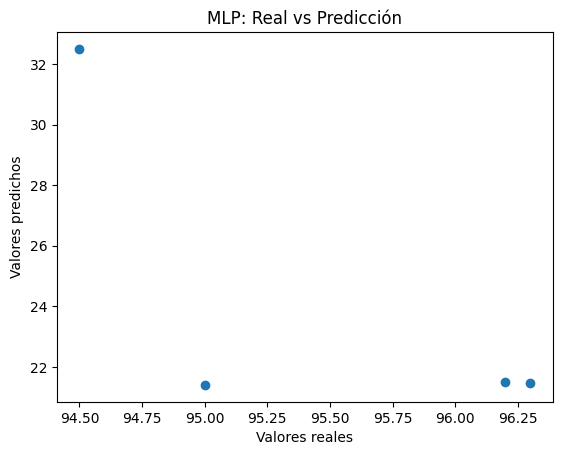

In [362]:
# Comparación visual de valores reales vs predichos

plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("MLP: Real vs Predicción")
plt.show()